# # 多層感知機從零開始實作
:label:`sec_mlp_scratch`

我們已經在 :numref:`sec_mlp`中描述了多層感知機（MLP），
現在讓我們嘗試自己實現一個多層感知機。
為了與之前softmax回歸（ :numref:`sec_softmax_scratch` ）
獲得的结果進行比較，
我們將繼續使用Fashion-MNIST圖像分類數據集
（ :numref:`sec_fashion_mnist`）。


In [1]:
import torch
from torch import nn

Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.
Intel MKL WARNING: Support of Intel(R) Streaming SIMD Extensions 4.2 (Intel(R) SSE4.2) enabled only processors has been deprecated. Intel oneAPI Math Kernel Library 2025.0 will require Intel(R) Advanced Vector Extensions (Intel(R) AVX) instructions.


In [2]:
batch_size = 256
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 定義數據轉換
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# 加載訓練集
train_dataset = datasets.FashionMNIST(
    root='./data', 
    train=True, 
    download=True, 
    transform=transform
)

# 加載測試集
test_dataset = datasets.FashionMNIST(
    root='./data', 
    train=False, 
    download=True, 
    transform=transform
)

# 創建數據加載器
batch_size = 256  # 你可以根據需要調整批次大小
train_iter = DataLoader(
    train_dataset, 
    batch_size=batch_size, 
    shuffle=True
)

test_iter = DataLoader(
    test_dataset, 
    batch_size=batch_size, 
    shuffle=False
)
# 打印數據集大小
print(f"Training set size: {len(train_dataset)}")
print(f"Test set size: {len(test_dataset)}")

# 打印圖像大小和類別數
print(f"Image shape: {train_dataset[0][0].shape}")
print(f"Number of classes: {len(train_dataset.classes)}")

# 打印類別名稱
print("Class labels:", train_dataset.classes)

Training set size: 60000
Test set size: 10000
Image shape: torch.Size([1, 28, 28])
Number of classes: 10
Class labels: ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']


## 初始化模型参数

回想一下，Fashion-MNIST中的每个图像由
$28 \times 28 = 784$个灰度像素值组成。
所有图像共分为10个类别。
忽略像素之间的空间结构，
我们可以将每个图像视为具有784个输入特征
和10个类的简单分类数据集。
首先，我们将[**实现一个具有单隐藏层的多层感知机，
它包含256个隐藏单元**]。
注意，我们可以将这两个变量都视为超参数。
通常，我们选择2的若干次幂作为层的宽度。
因为内存在硬件中的分配和寻址方式，这么做往往可以在计算上更高效。

我们用几个张量来表示我们的参数。
注意，对于每一层我们都要记录一个权重矩阵和一个偏置向量。
跟以前一样，我们要为损失关于这些参数的梯度分配内存。


In [3]:
num_inputs, num_outputs, num_hiddens = 784, 10, 256

W1 = nn.Parameter(torch.randn(
    num_inputs, num_hiddens, requires_grad=True) * 0.01)
b1 = nn.Parameter(torch.zeros(num_hiddens, requires_grad=True))
W2 = nn.Parameter(torch.randn(
    num_hiddens, num_outputs, requires_grad=True) * 0.01)
b2 = nn.Parameter(torch.zeros(num_outputs, requires_grad=True))

params = [W1, b1, W2, b2]

## 激活函数

为了确保我们对模型的细节了如指掌，
我们将[**实现ReLU激活函数**]，
而不是直接调用内置的`relu`函数。


In [4]:
def relu(X):
    a = torch.zeros_like(X)
    return torch.max(X, a)

## 模型

因为我们忽略了空间结构，
所以我们使用`reshape`将每个二维图像转换为一个长度为`num_inputs`的向量。
只需几行代码就可以(**实现我们的模型**)。


In [5]:
def net(X):
    X = X.reshape((-1, num_inputs))
    H = relu(X@W1 + b1)  # 这里“@”代表矩阵乘法
    return (H@W2 + b2)

## 损失函数

由于我们已经从零实现过softmax函数（ :numref:`sec_softmax_scratch`），
因此在这里我们直接使用高级API中的内置函数来计算softmax和交叉熵损失。
回想一下我们之前在 :numref:`subsec_softmax-implementation-revisited`中
对这些复杂问题的讨论。
我们鼓励感兴趣的读者查看损失函数的源代码，以加深对实现细节的了解。


In [6]:
loss = nn.CrossEntropyLoss(reduction='none')

## 训练

幸运的是，[**多层感知机的训练过程与softmax回归的训练过程完全相同**]。
可以直接调用`d2l`包的`train_ch3`函数（参见 :numref:`sec_softmax_scratch` ），
将迭代周期数设置为10，并将学习率设置为0.1.


Using device: mps
Training on mps
epoch 1, loss 0.773, train acc 0.810, test acc 0.798
epoch 2, loss 0.493, train acc 0.835, test acc 0.822
epoch 3, loss 0.440, train acc 0.819, test acc 0.807
epoch 4, loss 0.409, train acc 0.834, test acc 0.817
epoch 5, loss 0.385, train acc 0.868, test acc 0.850
epoch 6, loss 0.370, train acc 0.868, test acc 0.850
epoch 7, loss 0.354, train acc 0.866, test acc 0.848
epoch 8, loss 0.345, train acc 0.869, test acc 0.849
epoch 9, loss 0.334, train acc 0.875, test acc 0.853
epoch 10, loss 0.323, train acc 0.890, test acc 0.872


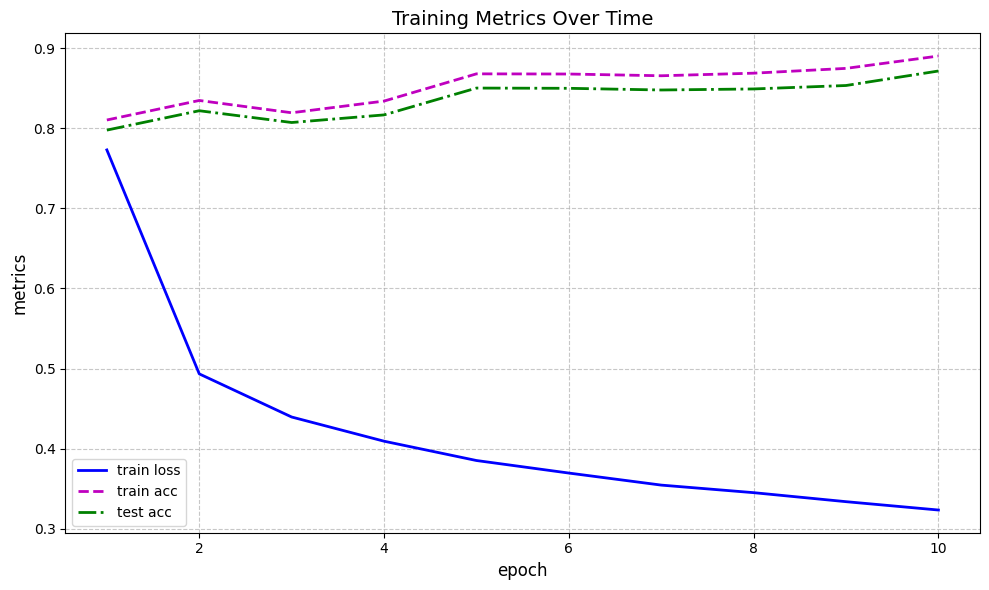


預測結果:
--------------------------------------------------
樣本 1:
預測標籤: Ankle boot
實際標籤: Ankle boot
預測正確
--------------------------------------------------
樣本 2:
預測標籤: Pullover
實際標籤: Pullover
預測正確
--------------------------------------------------
樣本 3:
預測標籤: Trouser
實際標籤: Trouser
預測正確
--------------------------------------------------
樣本 4:
預測標籤: Trouser
實際標籤: Trouser
預測正確
--------------------------------------------------
樣本 5:
預測標籤: Shirt
實際標籤: Shirt
預測正確
--------------------------------------------------
樣本 6:
預測標籤: Trouser
實際標籤: Trouser
預測正確
--------------------------------------------------


(['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser'],
 ['Ankle boot', 'Pullover', 'Trouser', 'Trouser', 'Shirt', 'Trouser'])

In [11]:
import torch
from torch import nn
import matplotlib.pyplot as plt
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

# 檢查設備
device = (
    "mps" if torch.backends.mps.is_available()
    else "cuda" if torch.cuda.is_available()
    else "cpu"
)
device = torch.device(device)
print(f'Using device: {device}')

# 定義模型類
class MLP(nn.Module):
    def __init__(self, num_inputs, num_hiddens, num_outputs):
        super().__init__()
        self.flatten = nn.Flatten()
        self.W1 = nn.Parameter(torch.randn(num_inputs, num_hiddens) * 0.01)
        self.b1 = nn.Parameter(torch.zeros(num_hiddens))
        self.W2 = nn.Parameter(torch.randn(num_hiddens, num_outputs) * 0.01)
        self.b2 = nn.Parameter(torch.zeros(num_outputs))
        
    def forward(self, X):
        X = self.flatten(X)
        H = relu(X@self.W1 + self.b1)
        return H@self.W2 + self.b2

def relu(X):
    return torch.max(X, torch.zeros_like(X))

def evaluate_accuracy(net, data_loader):
    """評估模型在數據集上的準確率"""
    net.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for X, y in data_loader:
            X, y = X.to(device), y.to(device)
            outputs = net(X)
            _, predicted = torch.max(outputs.data, 1)
            total += y.size(0)
            correct += (predicted == y).sum().item()
    return correct / total

def train_epoch(net, train_iter, loss_fn, optimizer):
    """訓練一個周期"""
    net.train()
    total_loss = 0
    total_samples = 0
    for X, y in train_iter:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        y_hat = net(X)
        loss = loss_fn(y_hat, y)
        loss.backward()
        optimizer.step()
        total_loss += float(loss.item() * X.shape[0])
        total_samples += X.shape[0]
    return total_loss / total_samples

def plot_metrics(epochs, train_losses, train_accs, test_accs):
    """繪製訓練指標圖表"""
    plt.figure(figsize=(10, 6))
    
    # 繪製曲線
    plt.plot(epochs, train_losses, 'b-', linewidth=2, label='train loss')
    plt.plot(epochs, train_accs, 'm--', linewidth=2, label='train acc')
    plt.plot(epochs, test_accs, 'g-.', linewidth=2, label='test acc')
    
    # 設置標籤和標題
    plt.xlabel('epoch', fontsize=12)
    plt.ylabel('metrics', fontsize=12)
    plt.title('Training Metrics Over Time', fontsize=14)
    
    # 設置圖例
    plt.legend(fontsize=10)
    
    # 設置網格
    plt.grid(True, linestyle='--', alpha=0.7)
    
    # 調整布局
    plt.tight_layout()
    plt.show()

def train(net, train_iter, test_iter, loss_fn, num_epochs, optimizer):
    """訓練模型並記錄訓練指標"""
    print(f'Training on {device}')
    
    # 儲存訓練指標
    train_losses = []
    train_accs = []
    test_accs = []
    
    for epoch in range(num_epochs):
        train_loss = train_epoch(net, train_iter, loss_fn, optimizer)
        train_acc = evaluate_accuracy(net, train_iter)
        test_acc = evaluate_accuracy(net, test_iter)
        
        # 儲存指標
        train_losses.append(train_loss)
        train_accs.append(train_acc)
        test_accs.append(test_acc)
        
        print(f'epoch {epoch + 1}, '
              f'loss {train_loss:.3f}, '
              f'train acc {train_acc:.3f}, '
              f'test acc {test_acc:.3f}')
    
    # 繪製訓練指標圖表
    plot_metrics(range(1, num_epochs + 1), train_losses, train_accs, test_accs)
    
    return train_losses, train_accs, test_accs

def predict(net, test_iter, n=6):
    """預測標籤"""
    net.eval()
    for X, y in test_iter:
        break
    X = X[0:n].to(device)
    y = y[0:n]
    
    with torch.no_grad():
        preds = net(X)
        predictions = torch.argmax(preds, dim=1).cpu().numpy()
        y = y.cpu().numpy()
    
    class_names = train_dataset.classes
    pred_labels = [class_names[i] for i in predictions]
    true_labels = [class_names[i] for i in y]
    
    print('\n預測結果:')
    print('-' * 50)
    for i, (pred, true) in enumerate(zip(pred_labels, true_labels)):
        print(f'樣本 {i+1}:')
        print(f'預測標籤: {pred}')
        print(f'實際標籤: {true}')
        print(f'預測{"正確" if pred == true else "錯誤"}')
        print('-' * 50)
    
    return pred_labels, true_labels

# 加載數據
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset = datasets.FashionMNIST(
    root='./data', train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(
    root='./data', train=False, download=True, transform=transform)

batch_size = 256
train_iter = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_iter = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# 創建模型實例
net = MLP(num_inputs=784, num_hiddens=256, num_outputs=10)
net = net.to(device)

# 設置訓練參數
num_epochs, lr = 10, 0.1
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=lr)

# 訓練模型
metrics = train(net, train_iter, test_iter, loss_fn, num_epochs, optimizer)

# 進行預測
predict(net, test_iter)

为了对学习到的模型进行评估，我们将[**在一些测试数据上应用这个模型**]。


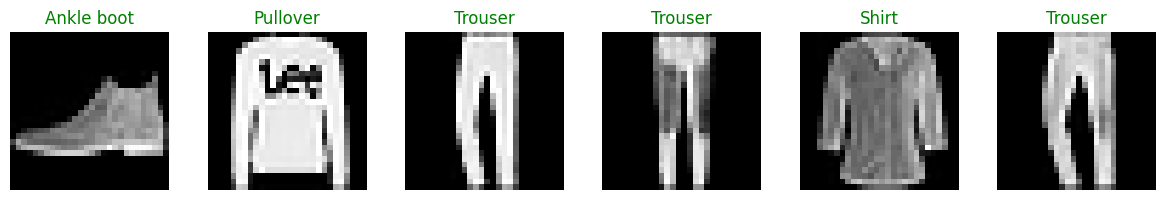

預測結果:
樣本 1: 預測=Ankle boot, 實際=Ankle boot
樣本 2: 預測=Pullover, 實際=Pullover
樣本 3: 預測=Trouser, 實際=Trouser
樣本 4: 預測=Trouser, 實際=Trouser
樣本 5: 預測=Shirt, 實際=Shirt
樣本 6: 預測=Trouser, 實際=Trouser


In [12]:
def predict_(net, test_iter, n=6):
    """預測標籤並顯示圖像"""
    net.eval()
    
    # 獲取一批數據
    for X, y in test_iter:
        break
    X, y = X[0:n].to(device), y[0:n]
    
    # 預測
    with torch.no_grad():
        preds = net(X)
        predictions = torch.argmax(preds, dim=1)
    
    # 設置圖表
    titles = [train_dataset.classes[pred] for pred in predictions]
    fig = plt.figure(figsize=(12, 2))
    
    # 顯示圖像和預測結果
    for i in range(n):
        plt.subplot(1, n, i + 1)
        plt.imshow(X[i].cpu().reshape(28, 28), cmap='gray')
        plt.axis('off')
        pred = titles[i]
        true = train_dataset.classes[y[i]]
        color = 'green' if pred == true else 'red'
        plt.title(pred, color=color)
    
    plt.tight_layout()
    plt.show()
    
    # 打印預測結果
    print("預測結果:")
    for i in range(n):
        pred = titles[i]
        true = train_dataset.classes[y[i]]
        print(f'樣本 {i+1}: 預測={pred}, 實際={true}')

# 使用新函數進行預測
predict_(net, test_iter)

## 小結

* 手動實現一個簡單的多層感知機是很容易的。然而如果有大量的層，從零開始實現多層感知機會變得很麻煩（例如，要命名和記錄模型的參數）。

## 練習

1. 在所有其他參數保持不變的情況下，更改超參數`num_hiddens`的值，並查看此超參數的變化對結果有何影響。確定此超參數的最佳值。
1. 嘗試添加更多的隱藏層，並查看它對結果有何影響。
1. 改變學習速率會如何影響結果？保持模型架構和其他超參數（包括輪數）不變，學習速率設置為多少會帶來最好的結果？
1. 通過對所有超參數（學習速率、輪數、隱藏層數、每層的隱藏單元數）進行聯合優化，可以得到的最佳結果是什麼？
1. 描述為什麼涉及多個超參數更具挑戰性。
1. 如果想要構建多個超參數的搜索方法，請想出一個聰明的策略。


[Discussions](https://discuss.d2l.ai/t/1804)


練習一:
1. 在所有其他參數保持不變的情況下，更改超參數`num_hiddens`的值，並查看此超參數的變化對結果有何影響。確定此超參數的最佳值。

我自己的回答:

為了確定最佳的 `num_hiddens`（隱藏層神經元數），首先需要明確此參數在模型中的作用：它決定了模型的容量和表達能力。`num_hiddens` 過小可能導致模型無法充分學習數據特徵，從而造成欠擬合；反之，過大的隱藏層雖然增強了模型的學習能力，但也更易過度擬合並增加計算成本。因此，平衡模型複雜度與訓練效率是選定 `num_hiddens` 的關鍵。

接著，可以依照以下流程進行實驗：先參考文獻或既有經驗，設定多組可能的 `num_hiddens` 值（例如 32、64、128、256、512），然後在固定其他超參數（如學習率、批次大小、優化器設定）的前提下，分別訓練模型。為了獲得可靠的模型效能，可以在驗證集上計算模型的指標（例如分類的準確度或迴歸的均方誤差），或採用交叉驗證的方式來減少數據分割帶來的波動。

在完成各個設定的訓練和評估後，將結果彙整並觀察其趨勢。可能出現的情況有：當 `num_hiddens` 增加時，模型的表現先上升、最後趨於平緩或開始下降。如果觀察到模型在某個區間取得最佳的指標表現，且過度擬合程度相對可控，就可以將該區間的 `num_hiddens` 值視為較佳選擇。若存在多個值在相似效能水準時，也可進一步比較訓練時間與推斷時間，再綜合考量運算資源分配，決定最終的最佳值。

總而言之，為了尋找最適合的 `num_hiddens`，需要同時兼顧指標表現、模型推斷效率以及避免過度擬合的風險。最終選定的 `num_hiddens` 通常是經過上述的系統性試驗後，能在實際任務中取得最佳平衡的數值。透過這樣的實驗流程，你就能有效地確定並驗證此超參數對結果的影響，並選出最恰當的設定。


練習二:

2. 嘗試添加更多的隱藏層，並查看它對結果有何影響。

我自己的回答:

在多層感知器（MLP）中添加更多的隱藏層，能夠增加模型的表達能力。多層結構可以讓模型學習到更高階、更抽象的特徵，尤其在處理複雜的資料（如影像、語言）時，可能取得更好的表現。然而，隨著隱藏層的增加，模型的參數量也會大幅成長，訓練過程對計算資源、資料量以及超參數調整的要求都更高。
  
當隱藏層太多且數據量不足時，模型容易陷入過度擬合（overfitting）的風險；這意謂著訓練集表現雖然優秀，但在測試集或實際應用場景中可能表現不佳。此外，過深的模型也會增加梯度消失（vanishing gradient）或梯度爆炸（exploding gradient）等問題，使訓練變得困難。儘管藉由批次正規化（Batch Normalization）、殘差連接（Residual Connections）等技術可以在一定程度上緩解這些問題，但這些技巧也會讓模型與訓練流程更複雜。

綜合而言，添加更多的隱藏層確實能提升模型的學習能力，但同時對資料規模、模型正規化方法和運算資源有更高的要求。在實務應用中，選擇適當的深度必須結合實驗驗證、資料特性、效能需求以及可行的訓練成本，從而達到最佳的平衡。


練習三:

3. 改變學習速率會如何影響結果？保持模型架構和其他超參數（包括輪數）不變，學習速率設置為多少會帶來最好的結果？


我自己的回答:

學習速率（learning rate）是深度學習中極其關鍵的超參數，因為它控制了每次梯度更新時參數調整的幅度。若學習速率過大，模型的參數更新會非常劇烈，可能導致訓練不穩定或梯度發散；若學習速率過小，則訓練過程會非常緩慢，甚至無法在合理的訓練輪數（epochs）內收斂至理想的結果。因此，選擇適當的學習速率對於模型的收斂速度與最終表現有顯著的影響。
  
在保持模型架構、訓練輪數和其他超參數不變的前提下，可以設置一個連續或離散的學習速率範圍（例如 `1e-4`, `5e-4`, `1e-3`, `5e-3`, `1e-2` 等），依序進行多組實驗。每組實驗都完整執行相同的訓練流程，並在驗證集上評估模型表現。通常會觀察指標（如準確度、損失值、F1-score 等）的曲線，特別留意是否出現收斂速度過慢、或在某些學習速率下出現發散的情況。

經過對不同學習速率的嘗試後，通常會發現一個「最佳區間」：在這個區間內，模型能以相對快速且穩定的方式進行收斂，且最終表現（驗證集指標）明顯優於太大或太小的學習速率。若要更進一步微調，可以在這個區間內使用更精細的步長，或採用動態調整學習速率（如學習速率衰減、Learning Rate Scheduler）來提升最終表現。
 
至於「學習速率設置為多少能帶來最好的結果」，並沒有一個放諸四海皆準的數值，因為最佳學習速率會受任務類型、資料特性、模型規模與初始化方式等多重因素影響。若僅就一般經驗值而言，初始學習速率多半落在 `1e-3` 到 `1e-2` 之間對大部分 MLP 或 CNN 類型的模型而言是較常見的選擇，然而仍需透過實驗與驗證數據來進行確定。最重要的是，應該採用系統化的實驗流程與觀察，並結合模型的學習曲線（Training & Validation Loss/Accuracy）來找到適合特定問題的最佳學習速率。

練習四:

4. 通過對所有超參數（學習速率、輪數、隱藏層數、每層的隱藏單元數）進行聯合優化，可以得到的最佳結果是什麼？

我自己的回答:
 
在進行所有超參數（學習速率、訓練輪數、隱藏層數以及每層的隱藏單元數）聯合優化時，通常會採用系統化的搜尋策略，如網格搜尋（Grid Search）、隨機搜尋（Random Search）或貝葉斯優化（Bayesian Optimization）等。其主要目的在於同時考慮多個超參數對最終表現的影響，並盡量在可接受的計算資源範圍內找出能讓模型表現最優的參數組合。

要獲得「最佳結果」，需基於任務需求與數據特性選擇合適的性能指標（例如分類問題的準確度、F1-score；回歸問題的 MSE、MAE；或其他更專業的評估方式）。在每次實驗中，都會根據這些指標在驗證集或使用交叉驗證（Cross-Validation）的方式進行評估，最後彙整所有參數組合的模型表現。

然而，「最佳」超參數組合因數據集、模型結構與運算資源不同而異，並沒有放諸四海皆準的固定值。以一般情境來說，若最終結果顯示：  
1. **學習速率**位於模型能穩定且快速收斂的區間（多數情況下可能在 `1e-3` 至 `5e-3` 間）。  
2. **訓練輪數**剛好足以使模型完成有效訓練而不過度擬合（可能落在幾十到上百個 Epoch 視資料而定）。  
3. **隱藏層數**通常為 2~4 層，能在表現和運算代價間取得平衡。  
4. **每層的隱藏單元數**在原始特徵量和任務複雜度的基礎上做調整，常見設置範圍可能為數十至數百。  

經過系統化測試後，常能在這些大致範圍內找出某個「甜蜜點」，其在驗證集或測試集上取得最理想的效果。

因此，最終的「最佳結果」往往是指在經過上述聯合優化與實驗流程後，依據特定性能指標在驗證集（或交叉驗證）中表現最好的那組參數設定（學習速率、輪數、隱藏層數、每層隱藏單元數），然後在測試集上取得的最終指標成績。若你需要具體的最佳結果數值，仍需針對特定資料集進行實際調參與實驗，才能得到最終的可量化指標。

練習五:

5. 描述為什麼涉及多個超參數更具挑戰性。

我自己的回答:

當同時考量多個超參數（例如學習速率、訓練輪數、隱藏層數與每層的隱藏單元數）時，最顯而易見的挑戰就是搜尋空間的急速擴張。若僅有一個超參數要調整，可以採用固定步長或範圍進行嘗試，但隨著超參數的增加，所需評估的參數組合將呈指數型增長，進而大幅提高實驗成本與所需的計算資源。

再者，不同超參數間往往存在交互影響（interaction）：例如，一個適用於高學習速率的最佳隱藏層數，不一定也適用於低學習速率；同樣地，若隱藏單元數過多，則可能需要調整學習速率或訓練輪數才能獲得良好結果。因此，無法單純針對某一超參數進行優化，必須同時考慮多個超參數的搭配與平衡。

除此之外，更多超參數也意味著更高的「試誤門檻」。若依賴傳統的網格搜尋（Grid Search），每增加一個超參數的可選範圍，都會使實驗組數呈現大爆炸式的提升。即使使用隨機搜尋（Random Search）或貝葉斯優化（Bayesian Optimization）等較有效率的方法，也仍需在更為複雜的多維參數空間中進行探索、評估與收斂。

因此，涉及多個超參數就需要更縝密的實驗設計和資源管理。除了要在廣闊的參數空間中以系統化方式搜尋，還需防範過度擬合與模型不穩定等問題。綜合而言，正是由於搜尋空間的爆炸性增長，以及不同超參數間的潛在交互作用，使得多超參數優化具備更高的挑戰性。

練習六:

6. 如果想要構建多個超參數的搜索方法，請想出一個聰明的策略。

我自己的回答加上AI的加強:

以下提供一個「分階段式」且相對「聰明」的多超參數搜尋策略，能在不過度消耗資源的情況下，逐步縮小搜尋範圍並逼近最佳解。此方法結合了隨機搜尋（Random Search）與貝葉斯優化（Bayesian Optimization）等技術，整體流程可分為下列階段：

---

### **第一階段：廣度探索（Exploration）**

1. **定義初始搜尋範圍**  
   - 為每個超參數設定一個較大的合理範圍（例如學習率可在 `1e-5 ~ 1e-1`，隱藏層數量 1~5 層，每層隱藏單元 32~1024 等），盡量包含可能的有效區域。

2. **進行隨機抽樣（Random Search）**  
   - 在此大範圍內先進行若干（如 20~50 組）的隨機抽樣。隨機搜尋比網格搜尋（Grid Search）在高維空間通常更有效率，且不會被固定間隔限制住。  
   - 每組超參數訓練完成後，記錄其在驗證集或交叉驗證的評估指標，作為「探索資料」。

3. **觀察初步結果**  
   - 找出在此階段表現相對較佳的參數組合（例如前 5~10 名），並同時注意哪些超參數值顯示「過大或過小」導致性能不佳，為後續縮小搜尋範圍做依據。

---

### **第二階段：貝葉斯優化（Bayesian Optimization）精修**

1. **在小範圍中採用貝葉斯優化**  
   - 針對表現較佳的組合區域，縮小每個超參數的搜尋範圍，如將原先學習率的範圍 `1e-5 ~ 1e-1` 縮至 `1e-4 ~ 1e-2`。  
   - 利用第一階段累積的「探索資料」（即參數組合—評估指標對）作為貝葉斯優化初始模型的訓練資料，接著透過貝葉斯優化（或 TPE, Gaussian Process 等方式）自動提議下一組參數進行評估。

2. **迭代更新模型**  
   - 每完成一組新的參數試驗，就更新貝葉斯優化的內部模型（如 GP 或 TPE），以便更準確預測哪些參數區域更有潛力。  
   - 讓優化程序在縮小的範圍內「探索—利用」（Exploration-Exploitation）平衡，快速找到高潛力的超參數組合。

3. **動態決定試驗次數**  
   - 可根據資源限制（如 GPU 時間）或取得的收斂速度，動態決定要進行多少次貝葉斯優化迭代。若發現模型性能提升已趨於飽和，便可進行最終評估與定案。

---

### **第三階段：復驗與微調**

1. **在擬定候選組合中進行深度驗證**  
   - 根據貝葉斯優化後的結果，通常會得到數個表現很接近的最佳候選組合。  
   - 在這幾組參數上進行更嚴格或更完整的驗證（例如加大訓練輪數、使用更嚴謹的交叉驗證），以確保模型在多種條件下都具備穩定表現。

2. **微調細節**  
   - 若在此階段發現某些超參數（例如學習率衰減策略、批次正規化等）可能進一步改善模型，可在最佳候選組合上做少量的微調測試。

3. **最終定案**  
   - 依據最終驗證或測試指標，選出表現最為穩定且優秀的參數組合，成為正式的超參數設定。  
   - 在最終測試集或實際任務上進行最後評估，獲得最終模型表現。

---

### **優點與注意事項**

- **優點**  
  - **快速收斂**：先透過隨機抽樣進行大範圍探索，避免錯失好區域；再用貝葉斯優化在潛力區域深度挖掘，提升搜索效率。  
  - **靈活度高**：可依照資源多寡和任務需求，隨時調整抽樣次數或優化迭代次數。  
  - **不易落入局部區域**：初期的隨機探索幫助我們不被固定間距或人工預設的參數區隔所侷限；貝葉斯優化則在縮小區域中持續嘗試新方向。

- **注意事項**  
  - **計算成本**：雖然此方法比單純的網格搜尋更有效率，但仍然需謹慎分配資源，特別是在參數空間仍大的情況下。  
  - **評估時間**：每次試驗都需要完整訓練或至少部分訓練（可考慮Early Stopping或中途終止），因此要評估計算時間與模型收斂程度間的平衡。  
  - **初始範圍設置**：第一階段若範圍設定過於狹窄，可能會錯失更多好區域；範圍過大則會造成大量無效訓練。因此建議先有個「合理上限與下限」的估算，再進行大範圍探索。

---

透過上述分階段式策略，能在大維度的超參數空間裡有效地搜尋高潛力區域，並藉由貝葉斯優化的「精修」機制，避免重複嘗試過多無效組合，最終找到相對最佳的參數設定。此方法相對「聰明」，也兼具靈活性與可擴充性，適合用於大多數深度學習的多超參數優化情境。